In [30]:
!pip install nlpaug

In [31]:
import os
import random
import re

import kagglehub
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
    pipeline,
 )

from nlpaug.augmenter.word import SynonymAug

In [32]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [33]:
SEED = 42
MODEL_NAME = "distilroberta-base"
MAX_LENGTH = 256
OUTPUT_DIR = "./bert_manipulation_model"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [34]:
# Download and load the psychological manipulation conversations dataset
path = kagglehub.dataset_download("tatheerabbas/psychological-manipulation-conversations-dataset")
file_path = os.path.join(path, "manipulational_conversation.jsonl")
raw_df = pd.read_json(file_path, lines=True)

Using Colab cache for faster access to the 'psychological-manipulation-conversations-dataset' dataset.


In [35]:
def build_max_sentiment_text(messages):
    if not isinstance(messages, list):
        return ""

    valid_messages = []
    for msg in messages:
        text = str(msg.get("text", "")).strip()
        if not text:
            continue

        # Prefer entries with explicit sentiment scores and pick the maximum.
        score = msg.get("sentiment_score", float("-inf"))
        try:
            score = float(score)
        except (TypeError, ValueError):
            score = float("-inf")

        valid_messages.append((score, text))

    if not valid_messages:
        return ""

    return max(valid_messages, key=lambda x: x[0])[1]

def normalize_label(row):
    if not bool(row.get("is_manipulation", False)):
        return "neutral"

    raw_label = str(row.get("manipulation_type", "")).lower().strip()
    raw_label = raw_label.replace("_", " ")
    raw_label = re.sub(r"\s+", " ", raw_label)

    aliases = {
        "gaslighting": "gaslighting",
        "love bombing": "love bombing",
        "guilt tripping": "guilt tripping",
        "guilt-trip": "guilt tripping",
        "passive aggressive": "passive-aggressive",
        "passive-aggression": "passive-aggressive",
        "charm": "charm/flattery",
        "flattery": "charm/flattery",
        "charm flattery": "charm/flattery",
        "charm/flattery": "charm/flattery",
        "direct coercion": "direct coercion",
    }

    return aliases.get(raw_label, "neutral")

records = []
for _, row in raw_df.iterrows():
    model_text = build_max_sentiment_text(row.get("messages", []))
    if not model_text:
        continue

    records.append({
        "conversation_id": row.get("conversation_id", ""),
        "text": model_text,
        "label": normalize_label(row),
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} usable conversations")
print(df["label"].value_counts())

Loaded 10000 usable conversations
label
neutral               1600
charm/flattery        1400
guilt tripping        1400
direct coercion       1400
gaslighting           1400
love bombing          1400
passive-aggressive    1400
Name: count, dtype: int64


In [36]:
# using an augmenter for synonym replacement with a 15% word replacement probability to try and combat some of the redundancy of synthetic data
text_augmenter = SynonymAug(aug_src='wordnet', aug_p=0.15)

In [37]:
# Define multiclass label space
label_list = [
    "gaslighting",
    "love bombing",
    "guilt tripping",
    "passive-aggressive",
    "charm/flattery",
    "direct coercion",
    "neutral",
]

df = df[df["label"].isin(label_list)].copy()
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}
df["labels"] = df["label"].map(label2id)

# Stratified train/validation/test split
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["labels"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["labels"],
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

# Apply data augmentation to the training set and ensure output is a single string
train_df['text'] = train_df['text'].apply(lambda x: text_augmenter.augment(x)[0])

train_dataset = Dataset.from_pandas(train_df[["text", "labels"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "labels"]], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["text", "labels"]], preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset = val_dataset.map(tokenize_batch, batched=True)
test_dataset = test_dataset.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

Train size: 8000
Validation size: 1000
Test size: 1000


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [39]:
# Train
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.277625,0.313805,0.896000,0.929583,0.896000,0.902450
2,0.266780,0.245671,0.909000,0.924748,0.909000,0.912053
3,0.228863,0.247372,0.912000,0.924091,0.912000,0.914249
4,0.353059,0.241956,0.909000,0.917507,0.909000,0.910752


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4000, training_loss=0.3172449867725372, metrics={'train_runtime': 267.9043, 'train_samples_per_second': 119.446, 'train_steps_per_second': 14.931, 'total_flos': 181980895492896.0, 'train_loss': 0.3172449867725372, 'epoch': 4.0})

In [40]:
# Evaluate on held-out test set
test_metrics = trainer.evaluate(test_dataset)
print("Test metrics:", test_metrics)

Test metrics: {'eval_loss': 0.24893811345100403, 'eval_accuracy': 0.917, 'eval_precision': 0.9279169071105515, 'eval_recall': 0.917, 'eval_f1': 0.9190175561986311, 'eval_runtime': 1.213, 'eval_samples_per_second': 824.404, 'eval_steps_per_second': 103.05, 'epoch': 4.0}


In [41]:
# Detailed per-class report
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)
print(classification_report(y_true, y_pred, target_names=label_list, digits=3))

                    precision    recall  f1-score   support

       gaslighting      1.000     0.893     0.943       140
      love bombing      0.865     0.957     0.908       140
    guilt tripping      0.876     0.907     0.891       140
passive-aggressive      1.000     0.929     0.963       140
    charm/flattery      1.000     0.893     0.943       140
   direct coercion      1.000     0.879     0.935       140
           neutral      0.777     0.956     0.857       160

          accuracy                          0.917      1000
         macro avg      0.931     0.916     0.920      1000
      weighted avg      0.928     0.917     0.919      1000



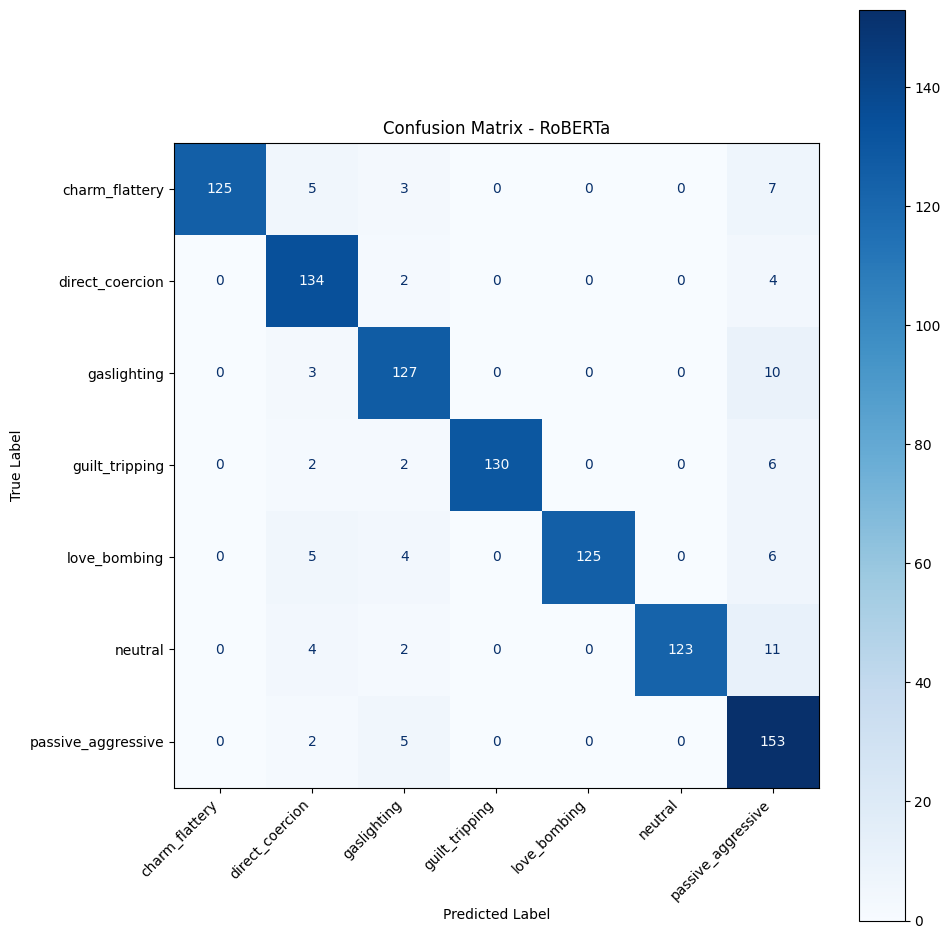

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

desired_order = [
    "charm_flattery",
    "direct_coercion",
    "gaslighting",
    "guilt_tripping",
    "love_bombing",
    "neutral",
    "passive_aggressive",
]

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=desired_order, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix - RoBERTa")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

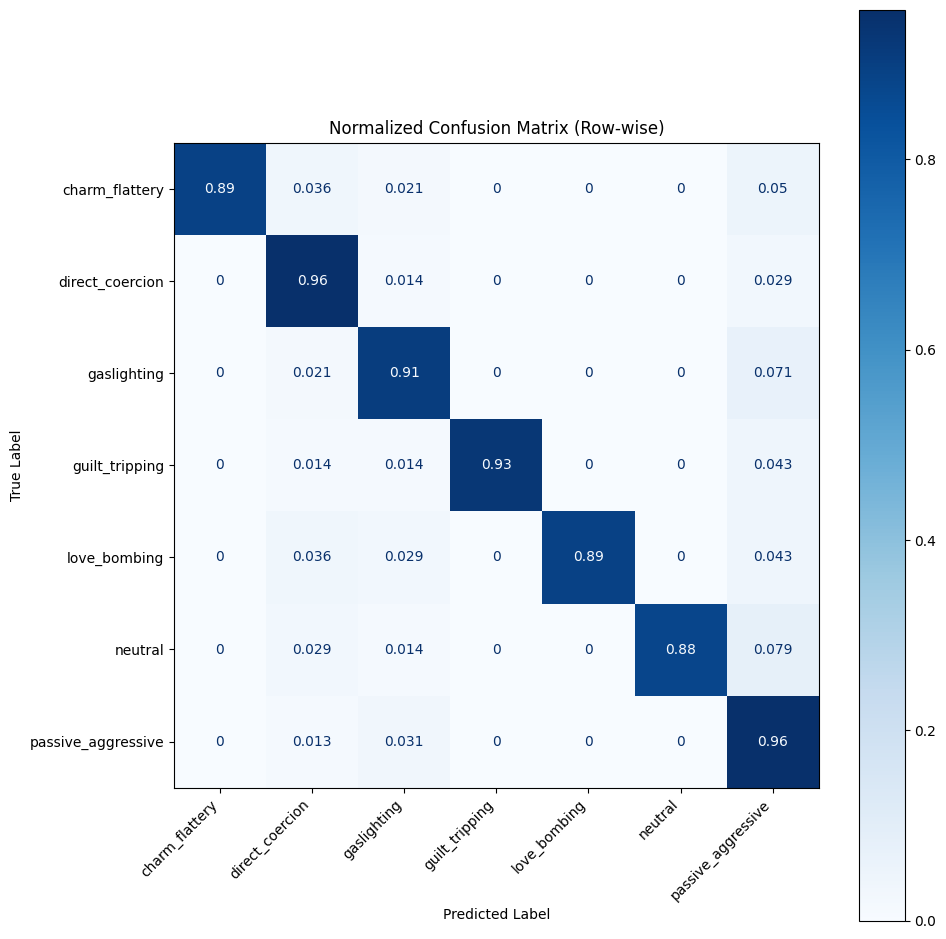

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

desired_order = [
    "charm_flattery",
    "direct_coercion",
    "gaslighting",
    "guilt_tripping",
    "love_bombing",
    "neutral",
    "passive_aggressive",
]

# Normalized Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=desired_order, cmap=plt.cm.Blues, normalize='true', ax=ax)
ax.set_title("Normalized Confusion Matrix (Row-wise)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

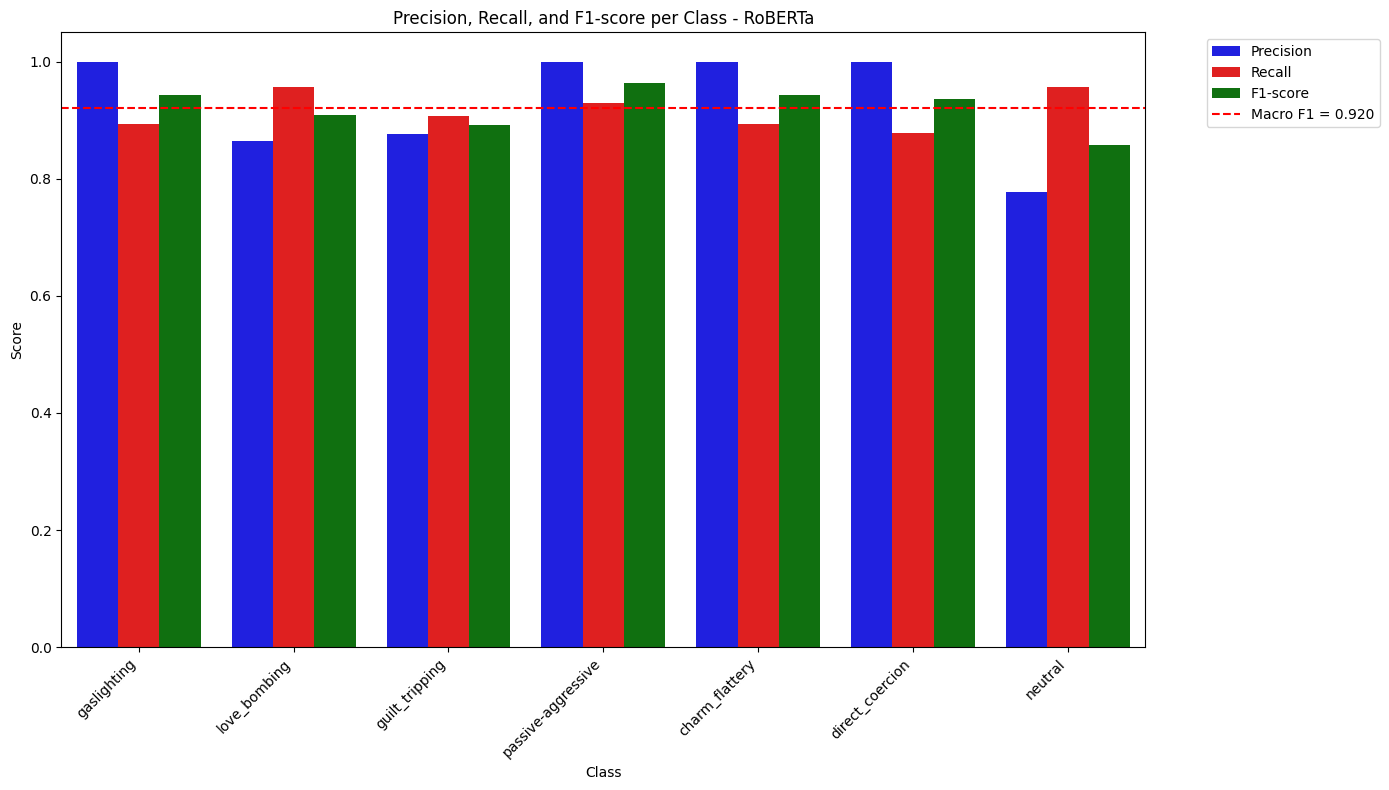

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score
import pandas as pd

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

# precision, recall, f1-score for each class
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=range(len(label_list)), average=None, zero_division=0)

# macro f1-score
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

metrics_df = pd.DataFrame({
    'Metric': ['Precision'] * len(label_list) + ['Recall'] * len(label_list) + ['F1-score'] * len(label_list),
    'Class': label_list * 3,
    'Score': list(precision) + list(recall) + list(f1)
})

metrics_df['Class'] = metrics_df['Class'].str.replace(' ', '_').str.replace('/', '_')

transformed_desired_order = [label.replace(' ', '_').replace('/', '_') for label in label_list]

metrics_df['Class'] = pd.Categorical(metrics_df['Class'], categories=transformed_desired_order, ordered=True)

# Plotting the metrics
fig = plt.figure(figsize=(14, 8))
sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df, palette=['blue', 'red', 'green'])
plt.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.3f}')

plt.title('Precision, Recall, and F1-score per Class - RoBERTa')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [45]:
# Save model and tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Saved fine-tuned model to: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to: ./bert_manipulation_model


In [46]:
# Example inference helper for new conversations
clf = pipeline(
    "text-classification",
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    truncation=True,
    max_length=MAX_LENGTH,
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [47]:
# Test with a simple string input
def predict_text(text):
    text = str(text).strip()
    if not text:
        raise ValueError("Input text cannot be empty.")
    return clf(text)

sample_text = "test"
print(predict_text(sample_text))

[{'label': 'neutral', 'score': 0.9938129186630249}]
